In [1]:
# Import Basic Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv('../data/European_Bank.csv')
df.head(5)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.drop(["CustomerId", "Surname"], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CreditScore      10000 non-null  int64  
 2   Geography        10000 non-null  object 
 3   Gender           10000 non-null  object 
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  int64  
 9   IsActiveMember   10000 non-null  int64  
 10  EstimatedSalary  10000 non-null  float64
 11  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [4]:
# Descriptive Statistics
df.describe()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: Index(['Geography', 'Gender'], dtype='object')
Numerical Columns: Index(['Year', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [6]:
# Encoding Categorical Variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df.head(5)


,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2025,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,2025,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [7]:
#check dummies
df.duplicated().sum()

0

In [8]:
# Check for missing values
print(df.isnull().sum())

Year               0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [9]:
# Feature Engineering
# 1. Create a new feature 'BalanceSalaryRatio'
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)  # Adding 1 to avoid division by zero
# 2. Product Density
df['ProductDensity'] = df['NumOfProducts'] / (df['Tenure'] + 1)  # Adding 1 to avoid division by zero
# 3. Engagement Interaction
df['EngagementScore'] = df['NumOfProducts'] * df['IsActiveMember']
# 4. Age Tenure Interaction
df['AgeTenureRatio'] = df['Age'] / (df['Tenure'] + 1)  # Adding 1 to avoid division by zero

In [10]:
df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementScore,AgeTenureRatio
0,2025,619,0,0,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,14.000000
1,2025,608,2,0,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,20.500000
2,2025,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,4.666667
3,2025,699,0,0,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,19.500000
4,2025,850,2,0,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,14.333333


In [11]:
# Split the dataset into features and target variable usind pipelines
X = df.drop(['Year', 'Exited'], axis=1)
y = df['Exited']

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Shape of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (8000, 14)
X_test shape: (2000, 14)
y_train shape: (8000,)
y_test shape: (2000,)


In [12]:
# Feature Scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Logistic Regression Pipeline
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

logreg_pipeline.fit(X_train, y_train)


# Decision Tree Pipeline
dt_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)


# Random Forest Pipeline
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)


# Gradient Boosting Pipeline
gb_pipeline = Pipeline([
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', GradientBoostingClassifier(random_state=42))])

In [14]:
# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

models = {
    'Logistic Regression': logreg_pipeline,
    'Decision Tree': dt_pipeline,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("-" * 50)

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.97      0.90      1607
           1       0.61      0.19      0.29       393

    accuracy                           0.82      2000
   macro avg       0.72      0.58      0.59      2000
weighted avg       0.79      0.82      0.78      2000

Confusion Matrix:
 [[1560   47]
 [ 319   74]]
Accuracy: 0.817
--------------------------------------------------
Model: Decision Tree
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1607
           1       0.46      0.50      0.48       393

    accuracy                           0.79      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.79      0.79      0.79      2000

Confusion Matrix:
 [[1379  228]
 [ 198  195]]
Accuracy: 0.787
--------------------------------------------------
Model: Random Forest
              precision    recall  f1-score   suppo

In [15]:
# ROC AUC score
from sklearn.metrics import roc_auc_score

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"Model: {name}, ROC AUC Score: {auc_score:.4f}")

Model: Logistic Regression, ROC AUC Score: 0.7653
Model: Decision Tree, ROC AUC Score: 0.6772
Model: Random Forest, ROC AUC Score: 0.8504
Model: Gradient Boosting, ROC AUC Score: 0.8668


In [18]:
# Feature Importance for Random Forest (Pipeline)

importances = rf_pipeline.named_steps["model"].feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

print(feature_importance_df)

               Feature  Importance
3                  Age    0.191591
9      EstimatedSalary    0.104422
0          CreditScore    0.104261
6        NumOfProducts    0.100677
13      AgeTenureRatio    0.098606
5              Balance    0.091728
10  BalanceSalaryRatio    0.082157
11      ProductDensity    0.053213
4               Tenure    0.040068
12     EngagementScore    0.039510
1            Geography    0.033686
8       IsActiveMember    0.025147
2               Gender    0.018686
7            HasCrCard    0.016248


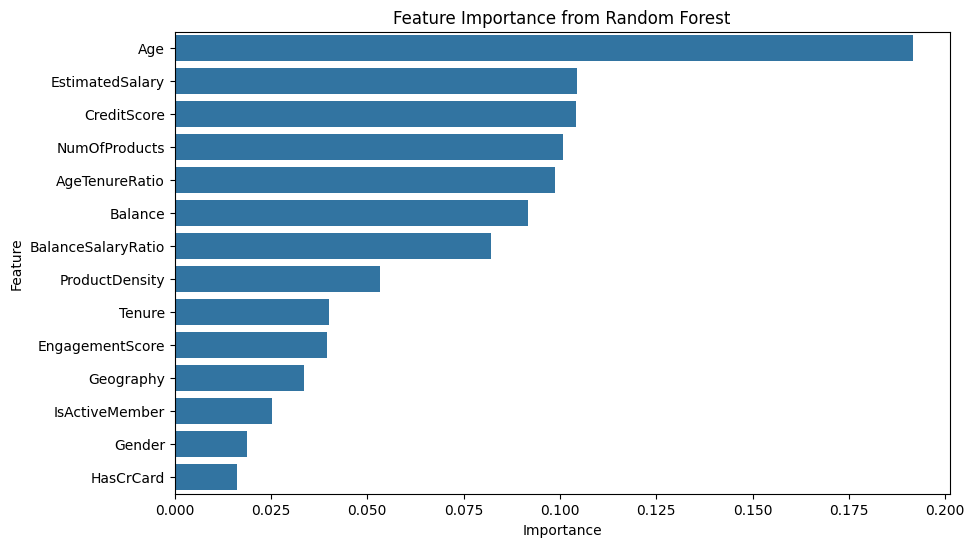

In [19]:
# Feature importance plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [20]:
# Save the best model (Pipeline)

import joblib

joblib.dump(rf_pipeline, '../models/churn_model.pkl')

['../models/churn_model.pkl']

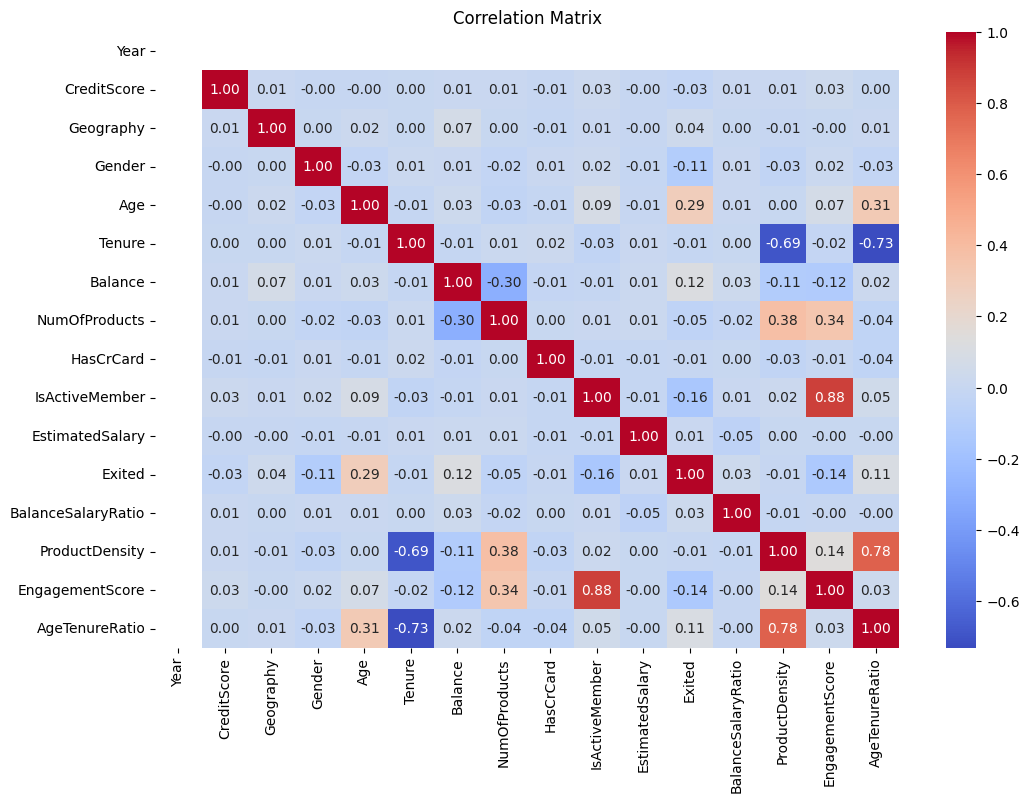

In [21]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [23]:
# Test the saved model (Pipeline)

import joblib

loaded_rf = joblib.load('../models/churn_model.pkl')

# data for testing
test_data = X_test.iloc[0].values.reshape(1, -1)

predicted_proba = loaded_rf.predict_proba(test_data)[:, 1]
prediction = loaded_rf.predict(test_data)

print(f"prediction: {prediction[0]}, predicted probability of churn: {predicted_proba[0]:.4f}")

prediction: 0, predicted probability of churn: 0.0200


c:\Users\kanch\Interships\interns\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\kanch\Interships\interns\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
